---
jupyter: python3
format:
  html:
    code-fold: true
    code-tools: true
bibliography: ../../references.bib
author:
  - name: XXXX
    id: dw
    orcid: XXXX
    email: XXXX
    corresponding: true
    degrees: PhD
    affiliation: 
      - name: The Alan Turing Institute
        city: London
        country: United Kingdom
        url: www.turing.ac.uk

---

# Data preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
sns.set()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
df = pd.read_csv('../data/outputs/analysis/street_summary_data.tsv', sep='\t')
# density is now number of individual divided by num street
# only taking into account the geocoded individuals and streets
# df['density'] = df['geocoded_inds'] / df['geocoded_streets']
df.columns

/var/folders/fg/_n1n9v7x7x1bk7m6gwfkv97m0000gp/T/ipykernel_14292/2160345481.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/outputs/analysis/street_summary_data.tsv', sep='\t')


Index(['Country', 'street_uid_comb', 'distance_comb', 'rail_density_100m_comb',
       'comb_src', 'ParID', 'RegCnty', 'SubDist', 'Parish', 'urban_class',
       'urban_class_mod', 'geocoded_inds', 'perc_hh_servants', 'CBD_num',
       'D_num', 'L_num', 'M_num', 'RW_num', 'T_num', 'other_num', 'CBD_perc',
       'D_perc', 'L_perc', 'M_perc', 'RW_perc', 'T_perc', 'other_perc',
       'streetname'],
      dtype='object')

In [3]:
# rename the columns to reduce changes to rest of notebook. values are not means though (since they're the scores for each street)
df = df.rename(columns={"rail_density_100m_comb":"mean_raildensity", "distance_comb":"mean_dist2station"})

In [21]:
df[["Country", "street_uid_comb", "mean_dist2station", "mean_raildensity", "comb_src", "RegCnty", "SubDist", "Parish", "urban_class_mod", "geocoded_inds", "perc_hh_servants", "CBD_perc", "D_perc", "RW_perc", "M_perc", "T_perc", "streetname"]].to_csv("../data/outputs/analysis/street_summary_data_slim.tsv", sep = "\t", index=False)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339950 entries, 0 to 339949
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Country            339950 non-null  object 
 1   street_uid_comb    339950 non-null  int64  
 2   mean_dist2station  339950 non-null  float64
 3   mean_raildensity   339340 non-null  float64
 4   comb_src           339950 non-null  object 
 5   ParID              339950 non-null  int64  
 6   RegCnty            339950 non-null  object 
 7   SubDist            290094 non-null  object 
 8   Parish             339950 non-null  object 
 9   urban_class        339950 non-null  int64  
 10  urban_class_mod    339950 non-null  int64  
 11  geocoded_inds      339950 non-null  int64  
 12  perc_hh_servants   339950 non-null  float64
 13  CBD_num            339950 non-null  int64  
 14  D_num              339950 non-null  int64  
 15  L_num              339950 non-null  int64  
 16  M_

In [4]:
df.geocoded_inds.describe()

count    339950.000000
mean         78.578067
std         172.809529
min           1.000000
25%           6.000000
50%          14.000000
75%          75.000000
max       10517.000000
Name: geocoded_inds, dtype: float64

In [5]:
# select a subset of places based on minimum number of people geo-coded to a street
df_high_density = df[df['geocoded_inds'] > 78].copy()
df_high_density.shape, df.shape

((82948, 28), (339950, 28))

In [6]:
# normalize the values in selected columns between -1 and 1 with 0 equal to the median
for col_name in   ['mean_raildensity','mean_dist2station']:
    vector = df_high_density[col_name]
    median_value = vector.median()

    # valculate the scaling factor to bring the median to 0
    scaling_factor = 1.0 / (np.max(vector) - median_value)

    # normalize the vector between -1 and 1 with the median at 0
    df_high_density[f'{col_name}_norm'] = (vector - median_value) * scaling_factor

df_high_density['combined'] = df_high_density['mean_raildensity_norm'] + df_high_density['mean_dist2station_norm']
df_high_density['combined'] = df_high_density['combined'] + abs(df_high_density['combined'].min())
df_high_density.fillna(.0, inplace=True)

In [7]:

# df_high_density['mean_raildensity_log'] = np.log(abs(df_high_density['mean_raildensity_norm'].min()) + .1 + df_high_density['mean_raildensity_norm'])
# df_high_density['mean_dist2station_log'] = np.log(abs(df_high_density['mean_dist2station_norm'].min()) + .1 + df_high_density['mean_dist2station_norm'])

# log-scale of variables
df_high_density['mean_raildensity_log'] = np.log(abs(df_high_density['mean_raildensity'].min()) + .1 + df_high_density['mean_raildensity'])
df_high_density['mean_dist2station_log'] = np.log(abs(df_high_density['mean_dist2station'].min()) + .1 + df_high_density['mean_dist2station'])


<Axes: ylabel='Frequency'>

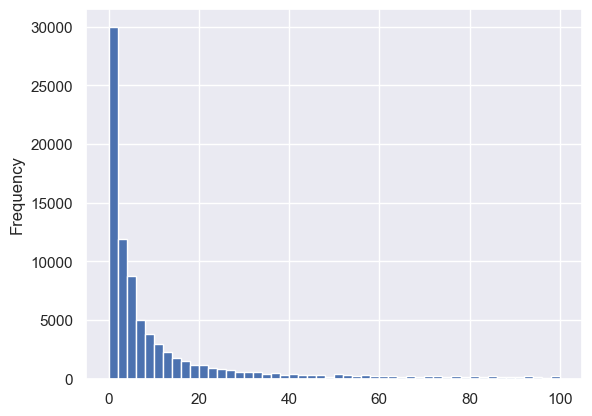

In [8]:
df_high_density['perc_hh_servants'].plot(kind='hist',bins=50)

In [9]:
df_high_density["perc_hh_servants"].describe([0.8, 0.9])

count    82948.000000
mean        11.292033
std         18.986527
min          0.000000
50%          3.846154
80%         15.730337
90%         33.333333
max        100.000000
Name: perc_hh_servants, dtype: float64

In [10]:

# convert continuous measure to categorical
df_high_density['perc_hh_servants_discr'] = 'low'
df_high_density.loc[(df_high_density['perc_hh_servants'] >= 5) & (df_high_density['perc_hh_servants'] < 33),'perc_hh_servants_discr'] = 'medium'
df_high_density.loc[(df_high_density['perc_hh_servants'] >= 33),'perc_hh_servants_discr'] = 'high'
df_high_density['perc_hh_servants_discr'].value_counts()


low       46815
medium    27569
high       8564
Name: perc_hh_servants_discr, dtype: int64

In [11]:
df_high_density.columns

Index(['Country', 'street_uid_comb', 'mean_dist2station', 'mean_raildensity',
       'comb_src', 'ParID', 'RegCnty', 'SubDist', 'Parish', 'urban_class',
       'urban_class_mod', 'geocoded_inds', 'perc_hh_servants', 'CBD_num',
       'D_num', 'L_num', 'M_num', 'RW_num', 'T_num', 'other_num', 'CBD_perc',
       'D_perc', 'L_perc', 'M_perc', 'RW_perc', 'T_perc', 'other_perc',
       'streetname', 'mean_raildensity_norm', 'mean_dist2station_norm',
       'combined', 'mean_raildensity_log', 'mean_dist2station_log',
       'perc_hh_servants_discr'],
      dtype='object')

<Axes: ylabel='Frequency'>

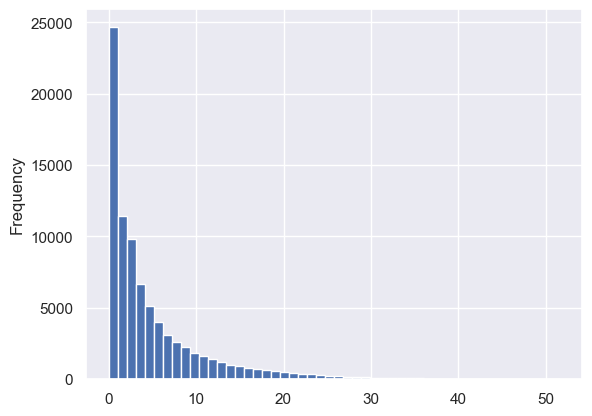

In [12]:
df_high_density['CBD_perc'].plot(kind='hist',bins=50)

In [13]:
df_high_density['CBD_perc_discr'] = 'low'
df_high_density.loc[(df_high_density['CBD_perc'] >= 4) & (df_high_density['CBD_perc'] < 7.5),'CBD_perc_discr'] = 'medium'
df_high_density.loc[(df_high_density['CBD_perc'] >= 7.5),'CBD_perc_discr'] = 'high'
df_high_density['CBD_perc_discr'].value_counts()

low       51690
high      17507
medium    13751
Name: CBD_perc_discr, dtype: int64

<Axes: ylabel='Frequency'>

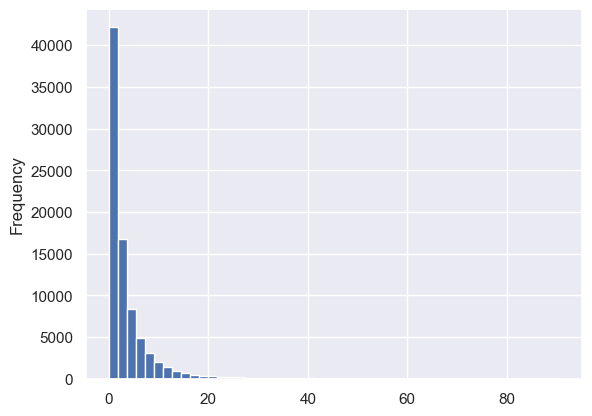

In [14]:
df_high_density['RW_perc'].plot(kind='hist',bins=50)

In [15]:
df_high_density['RW_perc_discr'] = 'low'
df_high_density.loc[(df_high_density['RW_perc'] >= 2.5) & (df_high_density['RW_perc'] < 5.0),'RW_perc_discr'] = 'medium'
df_high_density.loc[(df_high_density['RW_perc'] >= 5.0),'RW_perc_discr'] = 'high'
df_high_density['RW_perc_discr'].value_counts()

low       49993
high      17384
medium    15571
Name: RW_perc_discr, dtype: int64

In [16]:
df_high_density[df_high_density["SubDist"] == "Crewe"]["Parish"].value_counts()

MONKS COPPENHALL         120
HASLINGTON                 7
WILLASTON                  6
CHURCH COPPENHALL          4
SHAVINGTON CUM GRESTY      2
STAPELEY                   2
BLAKENHALL                 1
HOUGH                      1
WYBUNBURY                  1
Name: Parish, dtype: int64

# normalized plot with 4 quadrants

In [17]:
# normalized, size = individual, colour = servants

# place_filter = df_high_density["Parish"].str.contains("CAMBERWELL")
place_filter = df_high_density["SubDist"] == "Crewe"

fig = px.scatter(df_high_density[place_filter],
                 x="mean_raildensity",
                 size='geocoded_inds',
                 y="mean_dist2station",
                 color="CBD_perc_discr",
                 hover_data=['streetname','Parish',"RegCnty", "mean_raildensity", "mean_dist2station", "CBD_perc", "perc_hh_servants"],
                 width=1000, height=1000,
                 )
fig.update_layout(showlegend=False)
fig.show()

# map w/servant variable county comparison

In [ ]:
most_freq_counties = list(df_high_density.RegCnty.value_counts()[:5].index);
#most_freq_counties = [m.split('(')[0].strip() for m in most_freq_counties]
print('Plot includes',', '.join(most_freq_counties))


In [ ]:
# uncomment this to view n=20 counties ranked by frequency of occurence
# df_high_density.RegCnty.value_counts()[:20]

In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="perc_hh_servants_discr",
                 facet_row="RegCnty",
                 width=800, height=1600,
                 hover_data=['streetname', 'Parish',"RegCnty", "mean_raildensity", "mean_dist2station", "perc_hh_servants"],
                 category_orders={"perc_hh_servants_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="perc_hh_servants_discr",
                 facet_row="RegCnty",
                 facet_col='perc_hh_servants_discr',
                 width=1200, height=1200,
                 hover_data=['streetname','Parish',"RegCnty"],
                 category_orders={"perc_hh_servants_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

# repeat, but now with rail density (logged) on the y-axis and servants on the x-axis

In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="perc_hh_servants",
                 size='geocoded_inds',
                 y="mean_raildensity_log",
                 color="perc_hh_servants_discr",
                 facet_row="RegCnty",
                 width=800, height=1600,
                 hover_data=['streetname', 'Parish',"RegCnty"],
                 category_orders={"perc_hh_servants_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

# plot w/occupations CBD county comparison


In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="CBD_perc_discr",
                 facet_row="RegCnty",
                 #facet_col='CBD_perc_discr',
                 width=800, height=1200,
                 hover_data=['Parish',"RegCnty", "streetname"],
                 category_orders={"CBD_perc_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="CBD_perc_discr",
                 facet_row="RegCnty",
                 facet_col='CBD_perc_discr',
                 width=1200, height=1200,
                 hover_data=['streetname','Parish',"RegCnty"],
                 category_orders={"CBD_perc_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

# plot RWS county comparison

In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="RW_perc_discr",
                 facet_row="RegCnty",
                 #facet_col='CBD_perc_discr',
                 width=800, height=1200,
                 hover_data=['streetname','Parish',"RegCnty"],
                 category_orders={"RW_perc_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="RW_perc_discr",
                 facet_row="RegCnty",
                 facet_col='RW_perc_discr',
                 width=1200, height=1200,
                 hover_data=['streetname','Parish',"RegCnty"],
                 category_orders={"RW_perc_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

# Other Experiments

In [ ]:
fig = px.scatter(df_high_density,
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="perc_hh_servants",
                 facet_col="Country",
                 facet_row="urban_class_mod",
                 #trendline="ols",
                 width=1200, height=800,
                 hover_data=['streetname','Parish',"RegCnty"])
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
fig = px.scatter(df_high_density,
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="perc_hh_servants",
                 facet_row="perc_hh_servants_discr",
                 facet_col="urban_class_mod",
                 #trendline="ols",
                 width=1000, height=1000,
                 hover_data=['streetname','Parish',"RegCnty"],
                 category_orders={"perc_hh_servants_discr": ['low','medium','high']})
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
most_freq_counties = list(df_high_density.RegCnty.value_counts()[:5].index);
#most_freq_counties = [m.split('(')[0].strip() for m in most_freq_counties]
most_freq_counties

In [ ]:
fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="perc_hh_servants",
                 facet_row="RegCnty",
                 #facet_col="perc_hh_servants_discr",
                 #trendline="ols",
                 width=800, height=1600,
                 hover_data=['streetname','Parish',"RegCnty", "mean_raildensity", "mean_dist2station"],
                 category_orders={"perc_hh_servants_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()

In [ ]:

fig = px.scatter(df_high_density[df_high_density.RegCnty.isin(most_freq_counties)],
                 x="mean_raildensity_log",
                 size='geocoded_inds',
                 y="mean_dist2station_log",
                 color="perc_hh_servants",
                 facet_row="RegCnty",
                 facet_col="perc_hh_servants_discr",
                 #trendline="ols",
                 width=1200, height=2000,
                 hover_data=['streetname','Parish',"RegCnty"],
                 category_orders={"perc_hh_servants_discr": ['low','medium','high'],
                                  'RegCnty': most_freq_counties})
fig.update_layout(showlegend=False)
fig.show()